In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [ ]:
df = pd.read_csv('bi.csv',encoding='latin1')

In [ ]:
df.shape

(77, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fNAME          77 non-null     object 
 1   lNAME          77 non-null     object 
 2   Age            77 non-null     int64  
 3   gender         77 non-null     object 
 4   country        77 non-null     object 
 5   residence      77 non-null     object 
 6   entryEXAM      77 non-null     int64  
 7   prevEducation  77 non-null     object 
 8   studyHOURS     77 non-null     int64  
 9   Python         75 non-null     float64
 10  DB             77 non-null     int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 6.7+ KB


In [ ]:
df.dtypes

,0
fNAME,object
lNAME,object
Age,int64
gender,object
country,object
residence,object
entryEXAM,int64
prevEducation,object
studyHOURS,int64
Python,float64


In [ ]:
df.describe()

,Age,entryEXAM,studyHOURS,Python,DB
count,77.000000,77.000000,77.000000,75.000000,77.000000
mean,35.207792,76.753247,149.714286,75.853333,69.467532
std,10.341966,16.475784,12.743272,15.410328,17.033701
min,21.000000,28.000000,114.000000,15.000000,30.000000
25%,27.000000,69.000000,144.000000,71.000000,56.000000
50%,33.000000,80.000000,156.000000,81.000000,71.000000
75%,42.000000,90.000000,158.000000,85.000000,83.000000
max,71.000000,98.000000,160.000000,91.000000,100.000000


In [ ]:
df.head()

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.0,55
1,Alex,Walekhwa,60,M,Kenya,Private,79,Diploma,150,60.0,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,HighSchool,130,74.0,50
3,Shoni,Hlongwane,22,F,Rsa,Sognsvann,40,High School,120,NaN,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.0,80


In [ ]:
df.tail()

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
72,Clara,Bernard,43,Female,France,Private,80,Bachelors,150,75.0,43
73,Julian,Nielsen,31,Male,Denmark,Sognsvann,90,Masters,158,84.0,83
74,Sophie,Brown,33,Female,UK,Sognsvann,96,Masters,158,85.0,90
75,Leon,Bauer,35,Male,Germany,Sognsvann,90,Masters,160,87.0,74
76,Mohammed,Salim,31,Male,Somali,Sognsvann,35,Masters,144,72.0,90


In [ ]:
df.isnull().sum()

,0
fNAME,0
lNAME,0
Age,0
gender,0
country,0
residence,0
entryEXAM,0
prevEducation,0
studyHOURS,0
Python,2


In [ ]:
df['Python'].fillna('-1')

,Python
0,59.0
1,60.0
2,74.0
3,-1
4,91.0
...,...
72,75.0
73,84.0
74,85.0
75,87.0


In [ ]:
df['gender'].value_counts()

,count
gender,
Female,41
Male,32
M,1
F,1
female,1
male,1


In [ ]:
df['gender'] = df['gender'].replace({
    'Female':'F',
    'Male': 'M',
    'm':'M',
    'male':'M',
    'female':'F',
    'f':'F'
})

In [ ]:
df['gender'].value_counts()

,count
gender,
F,43
M,34


In [ ]:
df['gender'].str.strip().unique()

array(['F', 'M'], dtype=object)

In [ ]:
df['country'].value_counts()

,count
country,
Norway,47
Uganda,4
Kenya,3
Germany,3
Italy,2
Spain,2
Netherlands,2
Denmark,2
UK,2


In [ ]:
df['country']= df['country'].replace({
    'UK':'United Kingdom',
    'Rsa' : 'South Africa',
    'Norge' : 'Norway',
    'norway' : 'Norway',
    'Somali' : 'Somalia'
})

In [ ]:
df['country'].value_counts()

,count
country,
Norway,49
Uganda,4
Kenya,3
Germany,3
South Africa,2
Denmark,2
Netherlands,2
Spain,2
Italy,2


In [ ]:
df['residence'].value_counts()

,count
residence,
Private,33
BI Residence,29
Sognsvann,12
BI-Residence,1
BIResidence,1
BI_Residence,1


In [ ]:
df['residence'] = df['residence'].replace({
    'BI-Residence' :'BI Residence',
    'BIResidence' : 'BI Residence',
    'BI_Residence' : 'BI Residence'
})

In [ ]:
df['residence'].value_counts()

,count
residence,
Private,33
BI Residence,32
Sognsvann,12


In [ ]:
df['prevEducation'].value_counts()

,count
prevEducation,
Bachelors,24
High School,18
Masters,16
Diploma,9
Doctorate,5
HighSchool,1
Barrrchelors,1
diploma,1
DIPLOMA,1


In [ ]:
df['prevEducation'] = df['prevEducation'].replace({
    'diploma' : 'Diploma',
    'DIPLOMA' : 'Diploma',
    'Diplomaaa' : 'Diploma',
    'Barrrchelors' : 'Bachelors',
    'HighSchool' : 'High School',
    'Doctorate' : 'Doctor'
})

In [ ]:
df['prevEducation'].value_counts()

,count
prevEducation,
Bachelors,25
High School,19
Masters,16
Diploma,12
Doctor,5


In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR= Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower,upper)

4.5 64.5


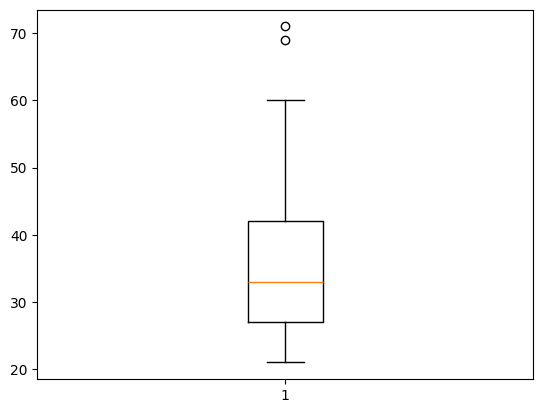

In [ ]:
plt.boxplot(df['Age'])
plt.show()

In [ ]:
df = df[(df["Python"] >= lower) & (df["Python"] <= upper)]

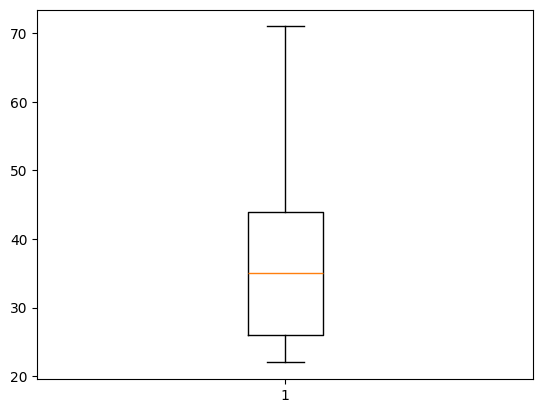

In [ ]:
plt.boxplot(df["Age"])
plt.show()

In [ ]:
Q1 = df['entryEXAM'].quantile(0.25)
Q3 = df['entryEXAM'].quantile(0.75)
IQR= Q3-Q1
lower = Q1 - 1.5 * IQR
uper = Q3 + 1.5 * IQR
print(lower,uper)

9.0 105.0


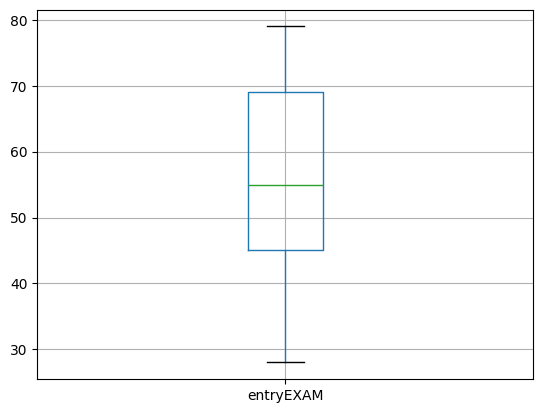

In [ ]:
df.boxplot('entryEXAM')
plt.show()

In [ ]:
Q1 = df['studyHOURS'].quantile(0.25)
Q3 = df['studyHOURS'].quantile(0.75)
IQR= Q3-Q1
lower = Q1 - 1.5 * IQR
uper = Q3 + 1.5 * IQR
print(lower,uper)

90.0 170.0


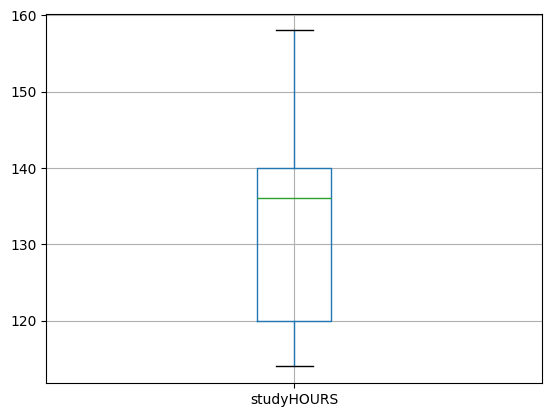

In [ ]:
df.boxplot('studyHOURS')
plt.show()

In [ ]:
Q1 = df['DB'].quantile(0.25)
Q3 = df['DB'].quantile(0.75)
IQR= Q3-Q1
lower = Q1 - 1.5 * IQR
uper = Q3 + 1.5 * IQR
print(lower,uper)

24.5 92.5


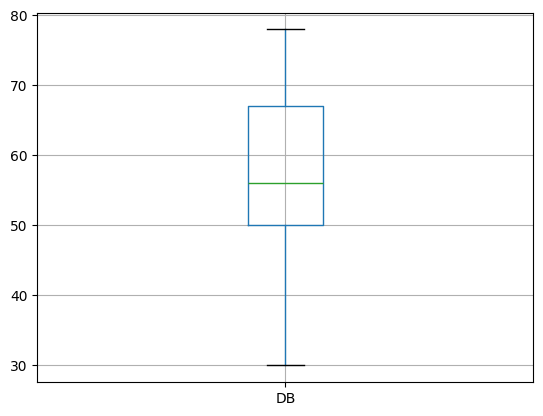

In [ ]:
df.boxplot('DB')
plt.show()

In [ ]:
Q1 = df['Python'].quantile(0.25)
Q3 = df['Python'].quantile(0.75)
IQR= Q3-Q1
lower = Q1 - 1.5 * IQR
uper = Q3 + 1.5 * IQR
print(lower,uper)

-7.5 100.5


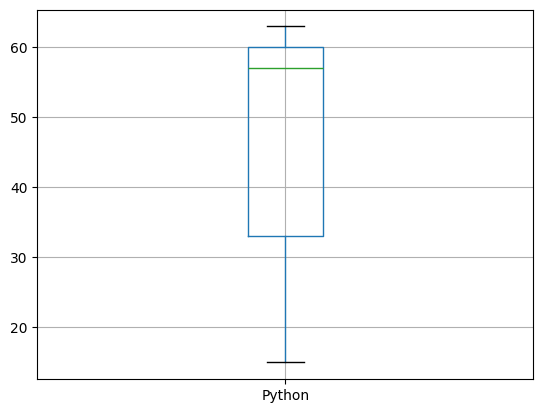

In [ ]:
df.boxplot('Python')
plt.show()

In [ ]:
le = LabelEncoder()

In [ ]:
df['gender'] = le.fit_transform(df['gender'])

In [ ]:
df['gender']

,gender
0,0
1,1
20,1
21,0
22,0
32,0
39,1
40,0
47,0
48,0


In [ ]:
df.sample(2)

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
1,Alex,Walekhwa,60,1,Kenya,Private,79,Diploma,150,60.0,75
40,Trond,Karlsen,37,0,Norway,Private,45,Bachelors,142,57.0,50


In [ ]:
num_cols = df.select_dtypes(include = ['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include = ['object']).columns.tolist()

df[num_cols] = df[num_cols].fillna(df[num_cols].median())


for cols in cat_cols:
    df[cols] = df[cols].fillna(df[cols].mode()[0])

encoder = LabelEncoder()

for cols in cat_cols:
    df[cols]= encoder.fit_transform(df[cols].astype(str))

X = df.drop(columns = ['fNAME','entryEXAM'])

y = df['entryEXAM']

In [ ]:
X.shape,y.shape

((13, 9), (13,))

In [ ]:
## Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state =42)

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVM": SVR(),
    "XGBoost": XGBRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred) * 100
    results[name] = r2
    print(f"{name:20} : {r2:.2f} %")

Linear Regression    : -97.91 %
Random Forest        : -70.17 %
Gradient Boosting    : -100.59 %
SVM                  : 1.15 %
XGBoost              : -104.11 %


/tmp/ipykernel_1266/3141877907.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Blues_d")


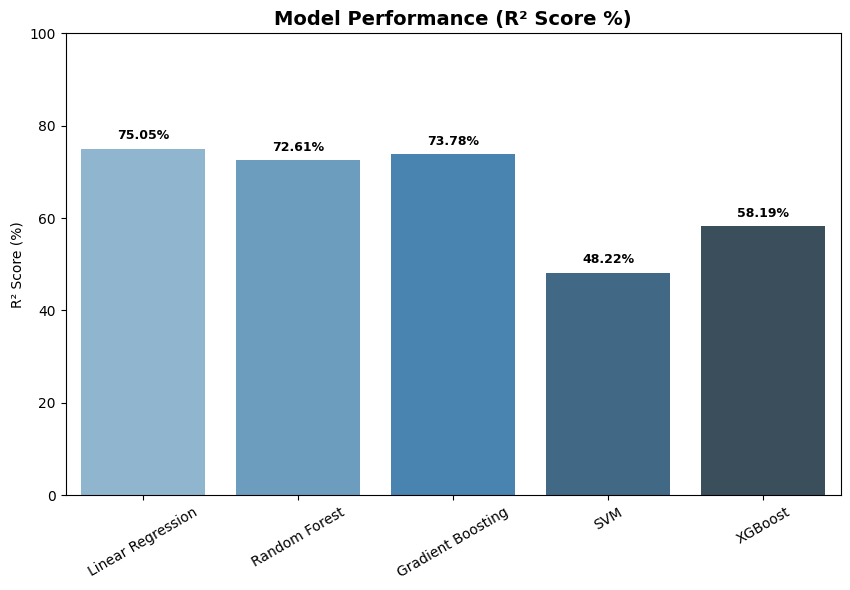

In [ ]:
results = {
    "Linear Regression": 75.05,
    "Random Forest": 72.61,
    "Gradient Boosting": 73.78,
    "SVM": 48.22,
    "XGBoost": 58.19
}

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="Blues_d")
plt.title("Model Performance (R² Score %)", fontsize=14, fontweight="bold")
plt.ylabel("R² Score (%)")
plt.ylim(0,100)
plt.xticks(rotation=30)

# Annotate values on top
for i, v in enumerate(results.values()):
    plt.text(i, v + 2, f"{v:.2f}%", ha="center", fontsize=9, fontweight="bold")

plt.show()